# MagmaClust - Distinct Input, Shared Hyperparameters, no Cluster Hyperparameters

---

## Setup

In [6]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [7]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from functools import partial
from copy import deepcopy

In [8]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

In [9]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

import kernax
kernax.config.parameter_transform = "softplus"  # Important for the stability of the optimisation
from kernax import WhiteNoiseKernel, SEKernel

import pandas as pd
from matplotlib import pyplot as plt

In [10]:
# Local
from MagmaClustPy.utils import split_db
from MagmaClustPy.means import ZeroMean
from MagmaClustPy.models import BaseLikelihood, MagmaClust

In [11]:
# Config
key = jax.random.PRNGKey(0)
test_db_size = "small"
nb_cluster = 4
pred_id = 0
grid_size = 250  # number of points in the grid
grid_margin = 5  # grid goes from min(all_inputs) - margin to max(all_inputs) + margin
train_pred_ratio = 0.8  # ratio of train/pred tasks
pred_test_ratio = 0.7  # ratio of pred/test points in each pred task

---

## Model use

##### Setup

In [12]:
db = pd.read_csv(f"./datasets/K={nb_cluster}/{test_db_size}_distinct_input_shared_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/opt/miniconda3/envs/MagmaPipelines/lib/python3.12/site-packages/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/opt/miniconda3/envs/MagmaPipelines/lib/python3.12/site-packages/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [13]:
mean_kernel = 50. * SEKernel(length_scale=1.3)
task_kernel_train = 1. * SEKernel(length_scale=1.2) + WhiteNoiseKernel(noise=2.)
task_kernel_pred = deepcopy(task_kernel_train)

In [14]:
model = MagmaClust(k=nb_cluster, likelihood=BaseLikelihood(), prior_mean=ZeroMean(), mean_kernel=mean_kernel, task_kernel_train=task_kernel_train, task_kernel_pred=task_kernel_pred, shared_hp=True, cluster_hp=False)

In [15]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [16]:
model.fit()

2026-04-21 11:51:53,668 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: 50.00 * SEKernel(length_scale=1.30)
	Task kernel: 1.00 * SEKernel(length_scale=1.20) + WhiteNoiseKernel(noise=2.00)
2026-04-21 11:51:55,499 - INFO - Iteration    1	Llhs:     112.6268,     565.3196	Conv. Ratio: inf	
	Mean kernel: 410.40 * SEKernel(length_scale=1.46)
	Task kernel: 4.41 * SEKernel(length_scale=0.84) + WhiteNoiseKernel(noise=0.07)
2026-04-21 11:51:56,554 - INFO - Iteration    2	Llhs:     113.7574,     536.6641	Conv. Ratio: 0.04060	
	Mean kernel: 410.40 * SEKernel(length_scale=1.47)
	Task kernel: 4.40 * SEKernel(length_scale=0.97) + WhiteNoiseKernel(noise=0.07)
2026-04-21 11:51:56,565 - INFO - Iteration    3	Llhs:     112.4583,     523.6241	Conv. Ratio: 0.02205	
	Mean kernel: 410.40 * SEKernel(length_scale=1.47)
	Task kernel: 4.54 * SEKernel(length_scale=1.05) + WhiteNoiseKernel(noise=0.07)
2026-04-21 11:51:56,574 - INFO - Iteration    4	Llhs:     112.2534,     5

In [17]:
model.generate_grid(grid_size)
model.grid_pred.shape

(250, 1)

In [18]:
pred_means, pred_covs = model.predict()
pred_means.shape, pred_covs.shape

((4, 4, 250), (4, 4, 250, 250))

##### Test

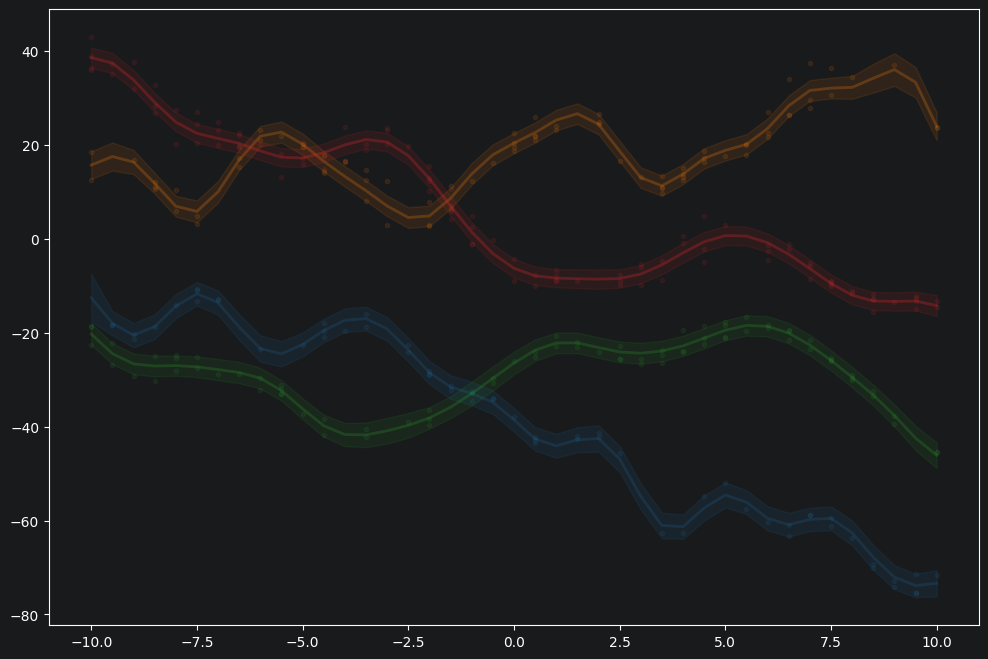

In [19]:
model.plot_mean_processes()
plt.show()

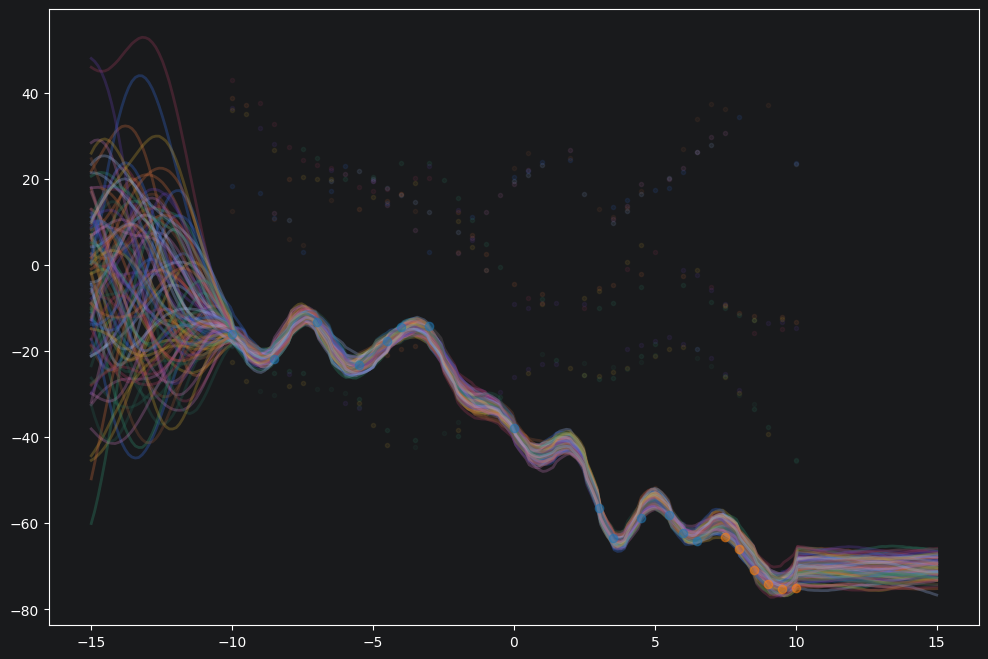

In [20]:
model.plot_predictions(plot_as="samples", task_id=0)
plt.show()

---